# Q3 : Image Warping and Homography
**Objective**  
Superimpose an image onto a planar surface in another image using a **projective transformation (homography)** estimated from four manually selected correspondences.

**Inputs**  
- A planar architectural image  
- An image to be warped (e.g., a flag)  
- Four pairs of corresponding points clicked manually on the target surface

**Method (Brief)**  
1. Select four points on a planar surface in the architectural image.  
2. Compute the 3 × 3 homography \( H \) that maps the flag image to this plane.  
3. Warp the flag image using `cv2.warpPerspective`.  
4. Blend the warped flag onto the architectural image using alpha blending.  
5. Repeat for at least two image pairs.

**Outputs**  
- Visual results of warped flag blended onto the chosen planar surfaces   
- Saved results under `../results/q3/`


## Initialization

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
DATA = Path("../data/q3")
RESULTS = Path("../results/q3")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image paths
IMG_PATH = DATA / "stanford_im1.png"
OVERLAY_PATH = DATA / "us_flag.png"

## Helper Functions

In [ ]:
def select_four_points(image, title="Select 4 points"):
    """Interactive function to select 4 points on an image."""
    points = []

    def click_event(event, x, y, flags, param):
        if event == cv.EVENT_LBUTTONDOWN:
            cv.circle(img_copy, (x, y), 5, (0, 255, 0), -1)
            cv.imshow(title, img_copy)
            points.append((x, y))
            print(f"Selected point {len(points)}: ({x}, {y})")

    img_copy = image.copy()
    cv.namedWindow(title)
    cv.setMouseCallback(title, click_event)
    print(
        f"Click 4 points on the planar surface in '{title}' (press 'q' to quit)")
    while len(points) < 4:
        cv.imshow(title, img_copy)
        if cv.waitKey(1) & 0xFF == ord('q'):
            break
    cv.destroyAllWindows()
    return np.array(points, dtype=np.float32)


def compute_homography(src_points, dst_points):
    """Compute homography matrix H that maps src_points to dst_points."""
    # findHomography with RANSAC
    H, _ = cv.findHomography(src_points, dst_points,
                             method=cv.RANSAC, ransacReprojThreshold=3.0)
    return H


def warp_and_blend(target_img, overlay_img, H, mask_alpha=0.7):
    """Warp overlay image using homography H and blend onto target image."""
    h, w = target_img.shape[:2]
    warped = cv.warpPerspective(
        overlay_img, H, (w, h), borderMode=cv.BORDER_TRANSPARENT)

    # Create mask for blending (optional: fade edges)
    mask = np.ones_like(warped, dtype=np.float32)
    mask[warped == 0] = 0  # Transparent where overlay is black

    # Blend: target * (1 - alpha) + overlay * alpha
    blended = target_img.astype(
        np.float32) * (1 - mask_alpha * mask) + warped.astype(np.float32) * (mask_alpha * mask)
    blended = np.clip(blended, 0, 255).astype(np.uint8)

    return blended

## Point Selection & Overlay Re-sizing

In [ ]:
# Load target image
target_path = IMG_PATH
    
target_img = cv.imread(target_path)
if target_img is None:
    raise FileNotFoundError(f"Could not load {target_path}")

# Load overlay image (flag)
overlay_path = OVERLAY_PATH

overlay_img = cv.imread(overlay_path)
if overlay_img is None:
    raise FileNotFoundError(f"Could not load {overlay_path}")

# Resize overlay to reasonable size
h_target, w_target = target_img.shape[:2]
overlay_img = cv.resize(overlay_img, (int(w_target*0.3), int(h_target*0.3)))

# Select 4 points on target image
print("\n--- SELECT 4 POINTS ON TARGET IMAGE ---")
target_points = select_four_points(
    target_img, "Select 4 points")

# Select 4 points on overlay image (corners of the flag)
print("\n--- SELECT 4 POINTS ON OVERLAY IMAGE ---")
overlay_points = select_four_points(
    overlay_img, "Select 4 points")

# Ensure correct order (clockwise or consistent)


--- SELECT 4 POINTS ON TARGET IMAGE ---
Click 4 points on the planar surface in 'Select 4 points' (press 'q' to quit)
Selected point 1: (698, 571)
Selected point 2: (1558, 303)
Selected point 3: (1567, 621)
Selected point 4: (699, 768)

--- SELECT 4 POINTS ON OVERLAY IMAGE ---
Click 4 points on the planar surface in 'Select 4 points' (press 'q' to quit)
Selected point 1: (6, 8)
Selected point 2: (605, 8)
Selected point 3: (604, 287)
Selected point 4: (5, 285)


## Computing Homography

In [19]:
# Compute homography
H = compute_homography(overlay_points, target_points)

# Warp and blend
result = warp_and_blend(target_img, overlay_img, H, mask_alpha=0.8)

## Visualizing Results

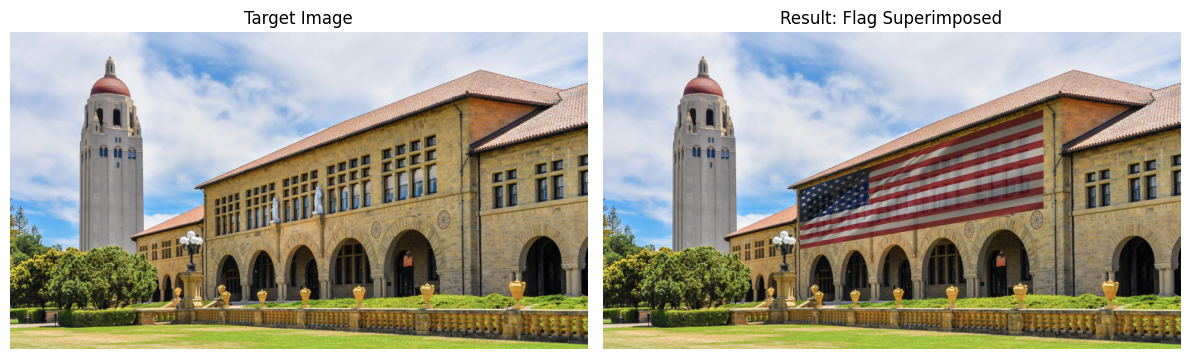


Result saved to: ../results/q3/final_superimposed.jpg


In [20]:
# Display result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(target_img, cv.COLOR_BGR2RGB))
plt.title("Target Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title("Result: Flag Superimposed")
plt.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / "q3_result.png", dpi=300, bbox_inches='tight')
plt.show()

# Save result
cv.imwrite(str(RESULTS / "final_superimposed.jpg"), result)
print(f"\nResult saved to: {RESULTS / 'final_superimposed.jpg'}")

## Visualizng Overlay Only

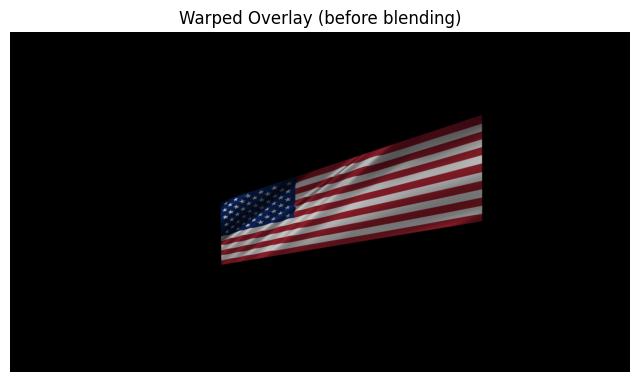

In [ ]:
# Visualize warped overlay
h, w = target_img.shape[:2]
warped_overlay = cv.warpPerspective(overlay_img, H, (w, h))

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(warped_overlay, cv.COLOR_BGR2RGB))
plt.title("Warped Overlay (before blending)")
plt.axis('off')
plt.savefig(RESULTS / "q3_warped_only.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import cv2 as cv
import os
import signal

# Close all OpenCV windows (standard)
cv.destroyAllWindows()
cv.waitKey(1)  # Required on some systems to flush events

# Extra cleanup: destroy all windows again (sometimes needed)
for _ in range(5):
    cv.waitKey(1)
    cv.destroyAllWindows()

: 